<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo con Políticas epsilon-soft**

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "CliffWalking", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando obstáculos.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "CliffWalking"**:
Se carga el entorno "CliffWalking".

- **Funciones para Mostrar los Resultados**: Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.

##### **Código de la Instalación e Importación**
----

In [2]:
%%capture
#@title Instalamos gym
%pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]

In [3]:
#@title Importamos librerias
from environments.cliff import make_cliff_env
from algorithms.mc_on_policy import MCOnPolicy
from utils.plotting import plot_curve

In [4]:
#@title Importamos el entorno cliff walking
NUM_EPISODES = 5000
SEED = 100

env = make_cliff_env(seed=SEED)

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)

# Definimos las acciones
UP, RIGHT, DOWN, LEFT = 0,1,2,3

Número de estados: 48
Número de acciones: 4


## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
   - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de iteración de valor utilizando Monte Carlo.
  - Se usa una versión "on-policy" de Monte Carlo con políticas epsilon greedy sobre una política epsilon-soft.
  - Se basa en el criterio de todas las visitas.
  - Otro aspecto es que la actualización de los retornos no se realiza en el orden inverso a las visitas.

## **3. Experimentación**

- En esta sección, el algoritmo de Monte Carlo con la política epsilon (decaimiento) se ejecuta para el entorno de Cliff Walking.

- Se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

- Además, se prueba el escenario con epsilon con decaimiento exponencial suave de acuerdo a la expresión:  
  $$ \epsilon_t = \max(0.05, \epsilon_0 \cdot 0.995^t) $$

- Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

- Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

- También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

- Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

### **3.1 Representaciones Gráficas**

Se mostrará la función $f(t) = \frac{\sum_{i=1}^t R_i}{t}$ para $t = 1,2,\ldots, NumeroEpisodios$. Aquí, $R_i$ es la recompensa obtenida en el episodio $i$. Como las recompensas son negativas por cada paso y caídas en el acantilado, esta función reflejará la calidad del aprendizaje, es decir, cuán eficientemente el agente alcanza el objetivo evitando el acantilado.

### **3.2 Experimentación en el escenario con ϵ-decaimiento**

- Se realizan 5000 episodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo). Se aplica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ decreciente.

In [5]:
# @title Aprendizaje
mc_on = MCOnPolicy(
    env,
    epsilon=0.3,
    discount_factor=0.95,
    decay=True
)

mc_on_rewards, mc_on_lengths = mc_on.train(NUM_EPISODES)

Entrenando MC on-policy: 100%|██████████| 5000/5000 [00:31<00:00, 158.10it/s]


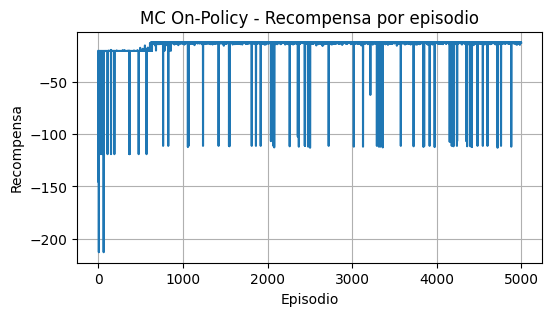

Máxima proporcion: -12.055713630835623


In [6]:
#@title Aciertos por número de episodios
plot_curve(
    mc_on_rewards,
    title="MC On-Policy - Recompensa por episodio",
    ylabel="Recompensa"
)
print(f"Máxima proporcion: {mc_on_rewards[-1]}")

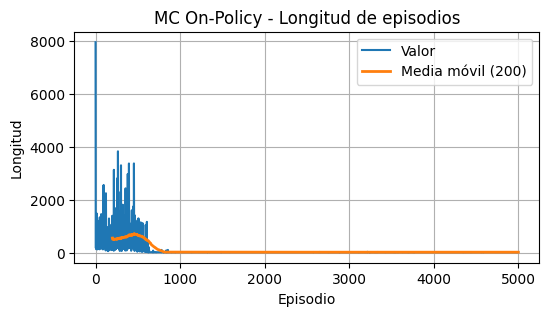

In [7]:
#@title Longitud de episodio por número de episodios
plot_curve(
    mc_on_lengths,
    title="MC On-Policy - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

In [8]:
# @title Tabla de valores Q
print("Valores Q para cada estado:\n", mc_on.Q)

Valores Q para cada estado:
 [[ -19.93628815  -14.04491511  -19.91503959  -19.95624971]
 [ -19.85744307  -13.13222678  -20.07280737  -19.92458219]
 [ -19.77113824  -11.9157709   -20.13791831  -20.04458165]
 [ -19.03065201  -10.54026801  -19.59092706  -19.57087329]
 [ -19.33609807   -9.1286115   -20.34032876  -19.68462785]
 [ -19.89666669   -8.86051305  -19.73255387  -18.25935221]
 [ -20.39268018  -12.31697517  -18.35338839  -18.21455358]
 [ -21.80785072   -7.62574605  -18.41085846  -19.20976349]
 [ -16.22751022   -6.4235164   -16.4108285   -17.75959529]
 [ -17.90528319   -5.12602723  -15.56872996  -23.18317073]
 [ -21.22194129  -14.56077151   -4.21771166  -14.57901964]
 [ -16.21323923  -21.14222812   -8.65211538  -16.73079689]
 [ -14.78308947  -21.82169328  -20.9946191   -17.08006027]
 [ -19.54756165  -40.94192226  -25.48602366  -24.91158839]
 [ -20.23184631  -30.67819206  -37.52063679  -41.58952903]
 [ -20.41293536  -12.10609947  -29.64537988  -36.0827108 ]
 [ -23.79049795  -15.054860

In [10]:
# @title Política final
pi, actions, grid = mc_on.greedy_policy_trajectory()
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", grid)
print()

Política óptima obtenida
 [[0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
 Acciones 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2 
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





### **3.3 Experimentación en el escenario sin ϵ-decaimiento**

- Se realizan 5000 episodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo). Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante.

In [11]:
# @title Aprendizaje
mc_on = MCOnPolicy(
    env,
    epsilon=0.3,
    discount_factor=0.95,
    decay=False
)

mc_on_rewards, mc_on_lengths = mc_on.train(NUM_EPISODES)

Entrenando MC on-policy: 100%|██████████| 5000/5000 [00:51<00:00, 97.87it/s] 


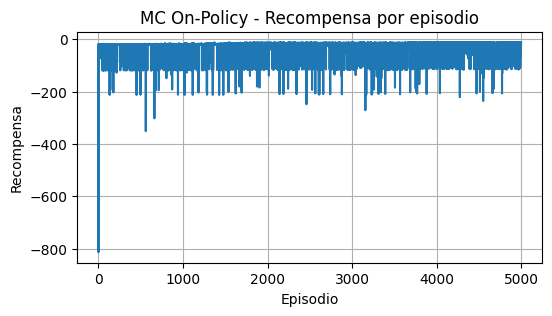

Máxima proporcion: -13.852862645499512


In [12]:
#@title Aciertos por número de episodios
plot_curve(
    mc_on_rewards,
    title="MC On-Policy - Recompensa por episodio",
    ylabel="Recompensa"
)
print(f"Máxima proporcion: {mc_on_rewards[-1]}")

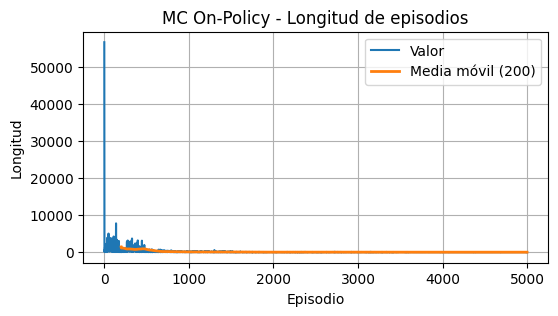

In [13]:
#@title Longitud de episodio por número de episodios
plot_curve(
    mc_on_lengths,
    title="MC On-Policy - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

In [14]:
# @title Tabla de valores Q
print("Valores Q para cada estado:\n", mc_on.Q)

Valores Q para cada estado:
 [[ -21.91213893  -19.38130349  -20.56791694  -19.86697532]
 [ -20.47635839  -18.56574097  -21.00322407  -20.86556698]
 [ -20.72598282  -18.18162014  -21.28158426  -20.48524131]
 [ -20.18559811  -18.29532805  -20.50898041  -20.10340409]
 [ -20.55743858  -17.42087617  -20.78512071  -20.69670073]
 [ -22.05293335  -13.74996498  -19.31358671  -20.33525255]
 [ -20.17363275  -14.11304456  -17.84399231  -19.22641124]
 [ -20.23864693  -12.08225194  -16.72077338  -18.05450689]
 [ -19.47100229  -12.92605794  -15.16541641  -16.45452332]
 [ -19.04441234  -13.16973282   -9.75661102  -15.36170976]
 [ -20.15834055  -11.25936869  -16.84115611  -17.1020167 ]
 [ -19.06812152  -12.55796148   -8.76702274  -14.2716243 ]
 [ -19.41703971  -21.89515885  -54.11801437  -22.82388001]
 [ -20.1014446   -21.78223247  -28.57148782  -38.91058902]
 [ -20.60024535  -21.66297629  -31.04812921  -24.25429394]
 [ -19.83784401  -20.50716509  -30.44490664  -21.65714843]
 [ -19.98363121  -20.099555

In [15]:
# @title Política final
pi, actions, grid = mc_on.greedy_policy_trajectory()
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", grid)
print()

Política óptima obtenida
 [[0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] 
 Acciones 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2 
 Para el siguiente grid
 o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  x





## **4. Fin**